# Land Use Cleaning (Colab)

This Colab notebook downloads two sample land-use rasters (A and B) from the GitHub repo and cleans them using `multiclean.clean_array`.

In [ ]:
%pip -q install multiclean rasterio matplotlib requests

In [1]:
from pathlib import Path
import requests
import numpy as np
import matplotlib.pyplot as plt
import rasterio as rio
from multiclean import clean_array

WORKDIR = Path.cwd() / "colab_data"
WORKDIR.mkdir(exist_ok=True)
A_URL = "https://raw.githubusercontent.com/DPIRD-DMA/MultiClean/main/notebooks/data/land%20use%20a.tif"
B_URL = "https://raw.githubusercontent.com/DPIRD-DMA/MultiClean/main/notebooks/data/land%20use%20b.tif"
A_PATH = WORKDIR / "land_use_a.tif"
B_PATH = WORKDIR / "land_use_b.tif"

print("Working directory:", WORKDIR)

Working directory: /Users/nick/Documents/Work Code/MultiClean/notebooks/colab_data


In [2]:
# Download A and B sample rasters from GitHub raw
def download(url, dst):
    if dst.exists():
        print("Exists:", dst)
        return
    print("Downloading", url)
    headers = {"User-Agent": "Mozilla/5.0"}
    with requests.get(url, stream=True, timeout=120, headers=headers) as r:
        r.raise_for_status()
        with open(dst, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
    print("Saved to", dst)


download(A_URL, A_PATH)
download(B_URL, B_PATH)
print("Done.")

Exists: /Users/nick/Documents/Work Code/MultiClean/notebooks/colab_data/land_use_a.tif
Exists: /Users/nick/Documents/Work Code/MultiClean/notebooks/colab_data/land_use_b.tif
Done.


In [3]:
# Load both rasters
with rio.open(A_PATH) as src:
    array_a = src.read(1)
with rio.open(B_PATH) as src:
    array_b = src.read(1)
print("A shape:", array_a.shape, "unique:", np.unique(array_a))
print("B shape:", array_b.shape, "unique:", np.unique(array_b))

A shape: (355, 330) unique: [  0 113 114 117 120 130 132 133 210 220 310 311 312 320 330 331 333 334
 335 338 340 341 343 345 348 353 420 430 431 433 435 438 439 440 441 443
 445 448 449 453 512 513 525 526 530 532 537 541 542 543 545 551 552 553
 565 567 571 572 580 582 591 592 593 600 610 621 622 630 631 640 641 650
 651 652 654]
B shape: (101, 99) unique: [113 115 116 117 120 130 133 210 220 320 330 331 333 349 433 438 541 543
 551 553 610 611 621 650 651]


In [4]:
# Clean both subsets with tailored parameters
clean_a = clean_array(array_a, smooth_edge_size=1, min_island_size=5, connectivity=8)
clean_b = clean_array(array_b, smooth_edge_size=3, min_island_size=10, connectivity=8)
print("A unique after:", np.unique(clean_a)[:10])
print("B unique after:", np.unique(clean_b)[:10])

A unique after: [  0 113 114 117 120 130 132 133 210 220]
B unique after: [113 115 116 117 120 133 210 220 320 331]


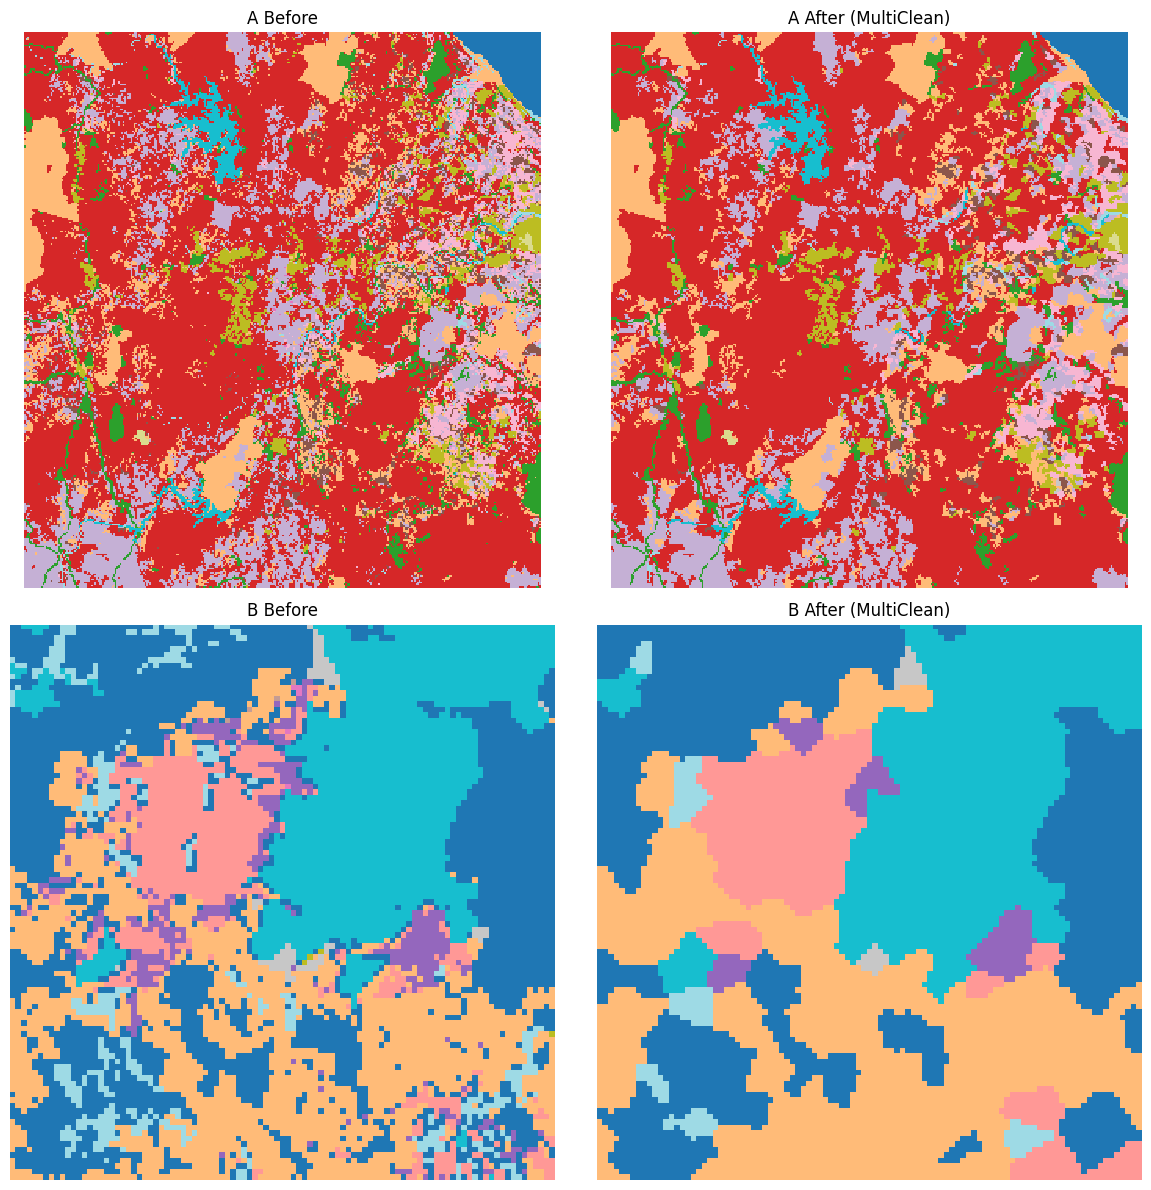

In [5]:
# Visualize side-by-side for A and B
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes[0, 0].imshow(array_a, cmap="tab20", interpolation="nearest")
axes[0, 0].set_title("A Before")
axes[0, 0].axis("off")
axes[0, 1].imshow(clean_a, cmap="tab20", interpolation="nearest")
axes[0, 1].set_title("A After (MultiClean)")
axes[0, 1].axis("off")
axes[1, 0].imshow(array_b, cmap="tab20", interpolation="nearest")
axes[1, 0].set_title("B Before")
axes[1, 0].axis("off")
axes[1, 1].imshow(clean_b, cmap="tab20", interpolation="nearest")
axes[1, 1].set_title("B After (MultiClean)")
axes[1, 1].axis("off")
plt.tight_layout()
plt.show()